# Configuración del Entorno y Descarga de Datos

 ## Instalación de librerías

In [ ]:
!pip install sentence-transformers faiss-cpu tqdm beautifulsoup4 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 63.2 MB/s eta 0:00:00


## Imports globales

In [ ]:
import json
import re
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from bs4 import BeautifulSoup

## Carga de datos

In [ ]:
REVIEWS_PATH = "/content/Digital_Music.jsonl"
META_PATH    = "/content/meta_Digital_Music.jsonl"

def load_jsonl(filepath):
    """Carga un fichero JSONL línea a línea y devuelve una lista de dicts."""
    records = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in tqdm(f, desc=f"Cargando {os.path.basename(filepath)}"):
            line = line.strip()
            if line:
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass  # saltamos líneas malformadas
    return records

# Carga ambos ficheros
reviews_raw = load_jsonl(REVIEWS_PATH)
meta_raw    = load_jsonl(META_PATH)

print(f"\nReseñas cargadas: {len(reviews_raw):,} registros")
print(f"Metadatos cargados: {len(meta_raw):,} registros")

Cargando Digital_Music.jsonl: 130434it [00:03, 39090.15it/s]
Cargando meta_Digital_Music.jsonl: 70537it [00:05, 11764.43it/s]


Reseñas cargadas: 130,434 registros
Metadatos cargados: 70,537 registros


## Inspección de la estructura

In [ ]:
print("EJEMPLO DE RESEÑA (reviews):")
print(json.dumps(reviews_raw[0], indent=2, ensure_ascii=False))

print("\nEJEMPLO DE METADATO (meta):")
print(json.dumps(meta_raw[0], indent=2, ensure_ascii=False))

EJEMPLO DE RESEÑA (reviews):
{
  "rating": 5.0,
  "title": "Nice",
  "text": "If i had a dollar for how many times I have played this cd and how many times I have asked Alexa to play it, I would be rich. Love this singer along with the Black Pumas. Finding a lot of new music that I like a lot on amazon. Try new things.",
  "images": [],
  "asin": "B004RQ2IRG",
  "parent_asin": "B004RQ2IRG",
  "user_id": "AFUOYIZBU3MTBOLYKOJE5Z35MBDA",
  "timestamp": 1618972613292,
  "helpful_vote": 0,
  "verified_purchase": true
}

EJEMPLO DE METADATO (meta):
{
  "main_category": "Digital Music",
  "title": "Baja Marimba Band",
  "average_rating": 4.9,
  "rating_number": 8,
  "features": [],
  "description": [],
  "price": null,
  "images": [
    {
      "thumb": "https://m.media-amazon.com/images/I/51kIbeVPzXL._SS40_.jpg",
      "large": "https://m.media-amazon.com/images/I/51kIbeVPzXL.jpg",
      "variant": "MAIN",
      "hi_res": null
    },
    {
      "thumb": "https://m.media-amazon.com/images/I/

## Resumen de campos disponibles

In [ ]:
# Campos en reseñas
review_keys = set()
for r in reviews_raw:
    review_keys.update(r.keys())

# Campos en metadatos
meta_keys = set()
for m in meta_raw:
    meta_keys.update(m.keys())

print(f"Campos en RESEÑAS  : {sorted(review_keys)}")
print(f"Campos en METADATOS: {sorted(meta_keys)}")

df_meta = pd.DataFrame(meta_raw)
print(f"\nShape del dataframe de metadatos: {df_meta.shape}")
print(f"\nNulos por columna (metadatos):\n{df_meta.isnull().sum()}")

Campos en RESEÑAS  : ['asin', 'helpful_vote', 'images', 'parent_asin', 'rating', 'text', 'timestamp', 'title', 'user_id', 'verified_purchase']
Campos en METADATOS: ['average_rating', 'bought_together', 'categories', 'description', 'details', 'features', 'images', 'main_category', 'parent_asin', 'price', 'rating_number', 'store', 'title', 'videos']

Shape del dataframe de metadatos: (70537, 14)

Nulos por columna (metadatos):
main_category          0
title                  0
average_rating         0
rating_number          0
features               0
description            0
price              30412
images                 0
videos                 0
store               4238
categories             0
details                0
parent_asin            0
bought_together    70537
dtype: int64


# Módulo I: procesado de ítems

In [ ]:
# Función de limpieza de texto

def clean_text(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    # 1. Eliminamos etiquetas HTML
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    # 2. Eliminamos caracteres de control y saltos de línea
    text = re.sub(r"[\r\n\t]+", " ", text)
    # 3. Eliminamos caracteres especiales, conservar letras, números y puntuación
    text = re.sub(r"[^\w\s\.,!?'\-]", " ", text)
    # 4. Minúsculas
    text = text.lower()
    # 5. Colapsamos espacios múltiples
    text = re.sub(r"\s+", " ", text).strip()
    return text

## Agregar reseñas por ítem

In [ ]:
from collections import defaultdict

# Agrupamos textos de reseñas por parent_asin
reviews_by_asin = defaultdict(list)

for review in tqdm(reviews_raw, desc="Agrupando reseñas por ítem"):
    asin = review.get("parent_asin") or review.get("asin")
    # Combinamos título y texto de la reseña
    parts = []
    if review.get("title"):
        parts.append(str(review["title"]))
    if review.get("text"):
        parts.append(str(review["text"]))
    combined = " ".join(parts).strip()
    if combined:
        reviews_by_asin[asin].append(combined)

# Concatenamos todas las reseñas de cada ítem (máximo 5 reseñas para no disparar el contexto)
MAX_REVIEWS_PER_ITEM = 5
reviews_text_by_asin = {}
for asin, texts in reviews_by_asin.items():
    merged = " | ".join(texts[:MAX_REVIEWS_PER_ITEM])
    reviews_text_by_asin[asin] = merged

print(f"\nÍtems con al menos una reseña: {len(reviews_text_by_asin):,}")

Agrupando reseñas por ítem: 100%|██████████| 130434/130434 [00:02<00:00, 63872.08it/s]



Ítems con al menos una reseña: 70,511


## Construcción del documento por ítem

In [ ]:
# Concatenamos metadatos + reseñas en un único texto limpio

def extract_item_document(meta_record, reviews_text_by_asin):
    """
    Construye el documento textual de un ítem a partir de sus metadatos
    y las reseñas agregadas de los usuarios

    Campos usados (en orden de relevancia):
      1. title          = nombre del álbum/canción
      2. store          = artista/sello discográfico
      3. categories     = géneros musicales
      4. features       = características destacadas
      5. description    = descripción larga
      6. details        = fecha de lanzamiento, etc.
      7. average_rating = valoración media
      8. reviews        = texto agregado de reseñas
    """
    asin  = meta_record.get("parent_asin", "")
    parts = []

    # 1. title
    title = clean_text(meta_record.get("title", ""))
    if title:
        parts.append(f"title: {title}")

    # 2. store
    store = clean_text(meta_record.get("store") or "")
    if store:
        parts.append(f"artist: {store}")

    # 3. categories
    cats = meta_record.get("categories", [])
    if isinstance(cats, list) and cats:
        cats_clean = [clean_text(c) for c in cats if isinstance(c, str) and c.strip()]
        if cats_clean:
            parts.append(f"genres: {', '.join(cats_clean)}")

    # 4. features
    feats = meta_record.get("features", [])
    if isinstance(feats, list) and feats:
        feats_clean = [clean_text(f) for f in feats if isinstance(f, str) and f.strip()]
        if feats_clean:
            parts.append(f"features: {' '.join(feats_clean)}")

    # 5. description
    desc = meta_record.get("description", [])
    if isinstance(desc, list):
        desc = " ".join([str(d) for d in desc if d])
    desc_clean = clean_text(desc)
    if desc_clean:
        parts.append(f"description: {desc_clean}")

    # 6. details
    details = meta_record.get("details", {})
    if isinstance(details, dict):
        for key, val in details.items():
            if val and isinstance(val, str):
                parts.append(f"{clean_text(key)}: {clean_text(val)}")

    # 7. average_rating
    avg_rating    = meta_record.get("average_rating")
    rating_number = meta_record.get("rating_number")
    if avg_rating is not None:
        parts.append(f"average rating: {avg_rating} out of 5 ({rating_number} reviews)")

    # 8. reviews  (reseñas agregadas)
    review_text = reviews_text_by_asin.get(asin, "")
    review_clean = clean_text(review_text)
    if review_clean:
        # limitamos a 500 caracteres para no llenar el vector con ruido
        parts.append(f"user reviews: {review_clean[:500]}")

    return " | ".join(parts)


# Construimos el corpus
corpus = []   # lista de dicts

for meta in tqdm(meta_raw, desc="Construyendo documentos"):
    doc = extract_item_document(meta, reviews_text_by_asin)
    if doc.strip():
        corpus.append({
            "asin"    : meta.get("parent_asin", ""),
            "title"   : clean_text(meta.get("title", "")),
            "document": doc
        })

df_corpus = pd.DataFrame(corpus)

print(f"\nÍtems en el corpus: {len(df_corpus):,} / {len(meta_raw):,}")
print(f"Ítems descartados (sin texto): {len(meta_raw) - len(df_corpus):,}")
print(f"\nLongitud media de documento: {df_corpus['document'].str.len().mean():.0f} caracteres")
print(f"Longitud máxima de documento: {df_corpus['document'].str.len().max():,} caracteres")
print(f"Longitud mínima de documento: {df_corpus['document'].str.len().min():,} caracteres")

Construyendo documentos: 100%|██████████| 70537/70537 [00:53<00:00, 1308.81it/s]



Ítems en el corpus: 70,537 / 70,537
Ítems descartados (sin texto): 0

Longitud media de documento: 702 caracteres
Longitud máxima de documento: 89,956 caracteres
Longitud mínima de documento: 102 caracteres


In [ ]:
# Verificación visual de ejemplos

print("EJEMPLOS DEL CORPUS PREPROCESADO:")
for i in [0, 100, 1000]:
    if i < len(df_corpus):
        row = df_corpus.iloc[i]
        print(f"\n[Ítem #{i}]")
        print(f"  ASIN   : {row['asin']}")
        print(f"  Título : {row['title']}")
        print(f"  Doc    : {row['document'][:400]}...")
        print("-" * 70)

EJEMPLOS DEL CORPUS PREPROCESADO:

[Ítem #0]
  ASIN   : B000V87RP2
  Título : baja marimba band
  Doc    : title: baja marimba band | date first available: february 28, 2010 | average rating: 4.9 out of 5 (8 reviews) | user reviews: baja marimba nostalgia circa 1964. i played this album until there wasn't a track left on it. of the very few albums this group put out, comin' in the back door was by far and away their best. a unique beat, reminiscent of a combination of bourbon street and old mexico, sup...
----------------------------------------------------------------------

[Ítem #100]
  ASIN   : B0002YL4Z4
  Título : outrageous
  Doc    : title: outrageous | artist: goads author format audio cd | description: the goads outrageous track title 1. just do it 2. no excuses 3. get out and show the plan 4. together forever 5. outrageous 6. we're dreaming with you 7. some will some won't soo what! 8. veterans of the u.s.a. | manufacturer: goadies | date first available: august 27, 2004 | l

# Módulo II: indexación y recuperación

## Carga del modelo de embeddings

In [ ]:
# Cargamos all-MiniLM-L6-v2

from sentence_transformers import SentenceTransformer
import torch

# detectamos si hay GPU disponible
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = "all-MiniLM-L6-v2"
model = SentenceTransformer(MODEL_NAME, device=device)

EMBEDDING_DIM = model.get_sentence_embedding_dimension()
print(f"\nModelo '{MODEL_NAME}' cargado")
print(f"Dimensión de embeddings: {EMBEDDING_DIM}\n")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Modelo 'all-MiniLM-L6-v2' cargado
Dimensión de embeddings: 384



/tmp/ipykernel_1695/2888126544.py:12: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  EMBEDDING_DIM = model.get_sentence_embedding_dimension()


## Generación de embeddings por lotes

In [ ]:
# Codificamos el corpus en lotes

import faiss
import time

# lista de documentos a codificar
documents = df_corpus["document"].tolist()

BATCH_SIZE = 512

print(f"Codificando {len(documents):,} documentos en lotes de {BATCH_SIZE}...")

embeddings = model.encode(
    documents,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=False   # normalizamos manualmente con FAISS
)

print(f"Dimensiones de la matriz de embeddings generada: {embeddings.shape}")

Codificando 70,537 documentos en lotes de 1024...


Batches:   0%|          | 0/69 [00:00<?, ?it/s]

Dimensiones de la matriz de embeddings generada: (70537, 384)


## Normalización L2 y creación del índice FAISS

In [ ]:
# al normalizar el producto escalar que calcula FAISS es equivalente a la similitud coseno

# Normalización L2 (in-place, modifica el array)
embeddings_normalized = embeddings.astype("float32")
faiss.normalize_L2(embeddings_normalized)
norms = np.linalg.norm(embeddings_normalized[:5], axis=1)

# Creación del índice
d = EMBEDDING_DIM
index = faiss.IndexFlatIP(d)
index.add(embeddings_normalized)

print(f"Índice FAISS creado:")
print(f"- Vectores: {index.ntotal:,}")
print(f"- Dimensión: {d}")

Índice FAISS creado:
- Vectores: 70,537
- Dimensión: 384


In [ ]:
# Guardamos el índice FAISS y el corpus

import pickle

INDEX_PATH  = "/content/digital_music.index"
CORPUS_PATH = "/content/digital_music_corpus.pkl"

# Guardamos el índice FAISS
faiss.write_index(index, INDEX_PATH)

# Guardamos el corpus
with open(CORPUS_PATH, "wb") as f:
    pickle.dump(df_corpus, f)

print(f"Índice FAISS guardado en  : {INDEX_PATH}")
print(f"Corpus guardado en        : {CORPUS_PATH}")

Índice FAISS guardado en  : /content/digital_music.index
Corpus guardado en        : /content/digital_music_corpus.pkl


## Construcción de perfiles de usuario

Construiremos 6 perfiles de usuario con dos estrategias combinadas:
- 3 perfiles reales extraídos del dataset (usuarios con varias reseñas)
- 3 perfiles sintéticos con preferencias musicales contradictorias

In [ ]:
# Identificamos los usuarios reales con más interacciones

from collections import Counter

# Contamos reseñas por usuario
user_review_counts = Counter(r["user_id"] for r in reviews_raw)

# Top 20 usuarios más activos
top_users = user_review_counts.most_common(20)
print(f"{'Rank':<6} {'user_id':<35} {'Nº reseñas'}")
print("-" * 55)
for i, (uid, count) in enumerate(top_users, 1):
    print(f"  {i:<4} {uid:<35} {count}")

Rank   user_id                             Nº reseñas
-------------------------------------------------------
  1    AGAFM74L2RIJ5O36NNYH4Z5ISQNQ        341
  2    AEDFM4VDH2MKYVBKGYVTU6R5L5FQ        182
  3    AH3FC6V3IUJIN2Y7BCZ7DN3IMMJQ        175
  4    AEFLICXXHRBMNT4HAZH2NUU6TCOA        136
  5    AFMUUMXTKB6C52CCENIFBK4QLT4Q        130
  6    AEIOEJHOTKH6PKPVPOF5CXMASJHQ        126
  7    AEBMZ7Q2F2EHZ4CTOCJDNQMHMZ3Q        113
  8    AGS3YH5GKIZCIPYFF3QKQAYBFYLA        111
  9    AEKGXJDXUVQKHP55JDGQXLXI6CYA        95
  10   AE6CHAOE2U5GBCM34AUGQGEJLYSA        83
  11   AEYSKBRH7VLMK55WAO3OAJN5ZJCA        80
  12   AGBM6SVUPA3UNXUI7SFN2ZXNJSZA        75
  13   AEMRMA2XQJP5W6YAP5QPY4ZZSUVA        70
  14   AG7CWHZGKQC7KXGECLXQGVZA4IAA        70
  15   AEODNRLGMJI2YNHX5CD2MF5BYMMQ        70
  16   AGOHH74RVZFZ3KRCHEI5BYNSBDVA        64
  17   AGBMSGWZ3CQDC65JMH45PVOCJKMA        63
  18   AFRDOQ4FWDVLDUY4JTMR2RF5YCRQ        62
  19   AE25K5V5RESPJ4WKCALB3ZVYYQPQ        62
  20   A

In [ ]:
# Construimos los perfiles de usuario a partir de sus reseñas
# (perfil = concatenación de documentos de los ítems valorados)

asin_to_doc   = dict(zip(df_corpus["asin"],   df_corpus["document"]))
asin_to_title = dict(zip(df_corpus["asin"],   df_corpus["title"]))

def build_real_user_profile(user_id, reviews_raw, asin_to_doc,
                             max_items=10, min_rating=4.0):
    """
    Construye el perfil de un usuario real concatenando los documentos
    de los ítems que valoró positivamente (rating >= min_rating)

    Devuelve (perfil_texto, lista_de_asins_consumidos)
    """
    # Filtramos sus reseñas positivas
    user_reviews = [
        r for r in reviews_raw
        if r["user_id"] == user_id and r.get("rating", 0) >= min_rating
    ]
    # Ordenamos por rating desc y limitamos
    user_reviews = sorted(user_reviews, key=lambda r: r["rating"], reverse=True)
    user_reviews = user_reviews[:max_items]

    profile_parts = []
    consumed_asins = []
    for r in user_reviews:
        asin = r.get("parent_asin") or r.get("asin")
        doc  = asin_to_doc.get(asin, "")
        if doc:
            profile_parts.append(doc)
            consumed_asins.append(asin)

    profile_text = " | ".join(profile_parts)
    return profile_text, consumed_asins


# Elegimos 3 usuarios reales de entre los más activos
REAL_USER_IDS = [top_users[0][0], top_users[1][0], top_users[2][0]]

real_profiles = {}
for uid in REAL_USER_IDS:
    text, asins = build_real_user_profile(uid, reviews_raw, asin_to_doc)
    real_profiles[uid] = {"text": text, "consumed": asins}
    print(f"Usuario {uid[:20]}:")
    print(f"- Ítems en perfil : {len(asins)}")
    print(f"- Títulos         : {[asin_to_title.get(a,'?') for a in asins[:5]]}")
    print(f"- Perfil (inicio) : {text[:200]}...\n")

Usuario AGAFM74L2RIJ5O36NNYH:
- Ítems en perfil : 10
- Títulos         : ['laborintus ii', 'symphonie n 2 et n 5 suite provençale - la création du monde', 'lumiere, musique des monasteres en aquitaine sequentia', 'brunetti 3 symphonies 2006-01-01', 'bach famous organ works']
- Perfil (inicio) : title: laborintus ii | artist: format audio cd | package dimensions: 5.55 x 4.97 x 0.54 inches 2.83 ounces | date first available: august 11, 2013 | number of discs: 1 | average rating: 4.5 out of 5 (...

Usuario AEDFM4VDH2MKYVBKGYVT:
- Ítems en perfil : 2
- Títulos         : ['not a second time', 'not a second time']
- Perfil (inicio) : title: not a second time | artist: the beatles artist format audio cd | description: this cd is an out of print collectible! it is the original 1992 one way records release. catalog ow 10845. there is...

Usuario AH3FC6V3IUJIN2Y7BCZ7:
- Ítems en perfil : 10
- Títulos         : ['debussy das gesamtwerk fuer klavier the complete piano works', 'tchaikovsky grieg pi

In [ ]:
# Perfiles sintéticos con preferencias musicales contradictorias

synthetic_profiles = {
    "user_synth_classical": {
        "text": (
            "i love classical music, especially baroque and romantic period compositions. "
            "my favorite composers are bach, beethoven, mozart, and chopin. "
            "i enjoy piano sonatas, symphonies, string quartets and orchestral works. "
            "i prefer studio recordings with excellent audio quality and historically "
            "informed performances. i dislike modern pop, rock or electronic music."
        ),
        "consumed": []
    },
    "user_synth_hiphop": {
        "text": (
            "i am a big fan of 90s and 2000s hip hop and rap music. "
            "i love artists like tupac, notorious b.i.g., jay-z, kendrick lamar and nas. "
            "i enjoy boom bap beats, conscious rap lyrics about street life and social issues. "
            "i also like r&b and soul influences mixed with hip hop production. "
            "i dislike country music, classical and heavy metal."
        ),
        "consumed": []
    },
    "user_synth_jazz": {
        "text": (
            "i am passionate about jazz music in all its forms: bebop, cool jazz, "
            "fusion, latin jazz and modern jazz. my favorite artists are miles davis, "
            "john coltrane, bill evans, pat metheny and charles mingus. "
            "i enjoy complex harmonies, improvisation and live concert recordings. "
            "i also appreciate crossover albums that blend jazz with blues or classical elements."
        ),
        "consumed": []
    }
}

print("Perfiles sintéticos definidos:")
for name, profile in synthetic_profiles.items():
    print(f"- {name}: {profile['text'][:120]}...")

Perfiles sintéticos definidos:
- user_synth_classical: i love classical music, especially baroque and romantic period compositions. my favorite composers are bach, beethoven, ...
- user_synth_hiphop: i am a big fan of 90s and 2000s hip hop and rap music. i love artists like tupac, notorious b.i.g., jay-z, kendrick lama...
- user_synth_jazz: i am passionate about jazz music in all its forms: bebop, cool jazz, fusion, latin jazz and modern jazz. my favorite art...


In [ ]:
# Consolidamos todos los perfiles en una estructura unificada lista para la recuperación

all_profiles = {}

# Perfiles reales
for i, (uid, data) in enumerate(real_profiles.items(), 1):
    all_profiles[f"user_real_{i}"] = {
        "label"   : f"Real User #{i} ({uid[:15]}...)",
        "text"    : data["text"],
        "consumed": data["consumed"]
    }

# Perfiles sintéticos
for name, data in synthetic_profiles.items():
    all_profiles[name] = {
        "label"   : name,
        "text"    : data["text"],
        "consumed": data["consumed"]
    }

print(f"{'ID':<28} {'Tipo':<12} {'Longitud texto'}")
print("-" * 60)
for pid, pdata in all_profiles.items():
    tipo = "Real" if "real" in pid else "Sintético"
    print(f"{pid:<28} {tipo:<12} {len(pdata['text'])} chars")

ID                           Tipo         Longitud texto
------------------------------------------------------------
user_real_1                  Real         8196 chars
user_real_2                  Real         1883 chars
user_real_3                  Real         7954 chars
user_synth_classical         Sintético    356 chars
user_synth_hiphop            Sintético    331 chars
user_synth_jazz              Sintético    355 chars


## Recuperación matricial

In [ ]:
# Embedding de perfiles + búsqueda matricial

K = 20   # recuperamos top-20 por usuario (el LLM usará los mejores)

profile_ids   = list(all_profiles.keys())
profile_texts = [all_profiles[pid]["text"] for pid in profile_ids]

query_embeddings = model.encode(
    profile_texts,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=False
)
query_embeddings = query_embeddings.astype("float32")
faiss.normalize_L2(query_embeddings)

print(f"Dimensiones de la matriz de consultas: {query_embeddings.shape}")

# BÚSQUEDA MATRICIAL (una sola llamada para todos los perfiles)
scores_matrix, indices_matrix = index.search(query_embeddings, K)

print(f"Recuperación completada:")
print(f"- scores_matrix  shape: {scores_matrix.shape}")
print(f"- indices_matrix shape: {indices_matrix.shape}")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Dimensiones de la matriz de consultas: (6, 384)
Recuperación completada:
- scores_matrix  shape: (6, 20)
- indices_matrix shape: (6, 20)


In [ ]:
# Visualización de resultados por perfil

print("TOP-5 ÍTEMS RECUPERADOS POR PERFIL:")

for i, pid in enumerate(profile_ids):
    label = all_profiles[pid]["label"]
    print(f"\n{label}")
    print(f"   Perfil: {all_profiles[pid]['text'][:120]}...")
    print(f"\n   {'Rank':<6} {'Score':<8} {'Título':<40} {'ASIN'}")
    print(f"   {'-'*75}")
    for rank in range(5):
        idx   = indices_matrix[i][rank]
        score = scores_matrix[i][rank]
        title = df_corpus.iloc[idx]["title"]
        asin  = df_corpus.iloc[idx]["asin"]
        print(f"   {rank+1:<6} {score:<8.4f} {title[:40]:<40} {asin}")

TOP-5 ÍTEMS RECUPERADOS POR PERFIL:

Real User #1 (AGAFM74L2RIJ5O3...)
   Perfil: title: laborintus ii | artist: format audio cd | package dimensions: 5.55 x 4.97 x 0.54 inches 2.83 ounces | date first ...

   Rank   Score    Título                                   ASIN
   ---------------------------------------------------------------------------
   1      0.8433   laborintus ii                            B000027NXM
   2      0.7002   symphodysse ii                           B002GEEG44
   3      0.6852   chapter one                              B0000259XY
   4      0.6694   again                                    B019MPEE4G
   5      0.6686   concierto                                B0000CBWYM

Real User #2 (AEDFM4VDH2MKYVB...)
   Perfil: title: not a second time | artist: the beatles artist format audio cd | description: this cd is an out of print collecti...

   Rank   Score    Título                                   ASIN
   -------------------------------------------------------

In [ ]:
# Guardamos los resultados

RETRIEVAL_PATH = "/content/retrieval_results.pkl"

retrieval_results = {
    "profile_ids"    : profile_ids,
    "all_profiles"   : all_profiles,
    "scores_matrix"  : scores_matrix,
    "indices_matrix" : indices_matrix,
    "K"              : K
}

with open(RETRIEVAL_PATH, "wb") as f:
    pickle.dump(retrieval_results, f)

print(f"Resultados de recuperación guardados en: {RETRIEVAL_PATH}")

Resultados de recuperación guardados en: /content/retrieval_results.pkl


# Módulo III: aumentación

In [ ]:
# Construimos el prompt aumentado en inglés (el dataset está en inglés)

def build_prompt(user_profile_text, retrieved_items, top_k_for_llm=10):
    """
    Parámetros:
        user_profile_text : texto del perfil del usuario
        retrieved_items   : lista de dicts con 'rank', 'title', 'asin', 'score', 'document'
        top_k_for_llm     : cuántos ítems pasar al LLM (de los K recuperados)

    Devuelve:
        str : prompt completo listo para enviar al LLM
    """

    items = retrieved_items[:top_k_for_llm]

    candidates_text = ""
    for item in items:
        candidates_text += (
            f"\n  - Título: \"{item['title']}\""
            f" | ASIN: {item['asin']}"
            f" | Score FAISS: {item['score']:.4f}"
            f" | Descripción: {item['document'][:300]}..."
        )

    prompt = f"""You are a Digital Music recommendation system.
Your goal is to analyze a user profile and select, from a list of retrieved candidates,
the options that best match their current musical tastes.

---
USER PROFILE:
The user has defined their current preferences as:
"{user_profile_text[:600]}"

---
RETRIEVED CANDIDATES (pre-ranked by semantic similarity):
{candidates_text}

---
INSTRUCTIONS (follow strictly):
1. RE-RANKING: Select and order the TOP 3 items from highest to lowest real affinity with the user profile.
2. JUSTIFICATION: For each item, write one short sentence explaining why it fits what the user is looking for, mentioning specific details from the description or metadata.
3. QUALITY FILTER: If a retrieved item is completely irrelevant to the user profile, ignore it.
4. INTEGRITY: Do NOT invent or suggest any item that is not in the candidate list above. Only use the exact titles provided.

---
OUTPUT FORMAT:
Return your response STRICTLY as a valid JSON array, with no additional text, no markdown, no explanation outside the JSON.
Use exactly this structure:
[
  {{
    "ranking": 1,
    "title": "Exact title from the candidate list",
    "asin": "ASIN from the candidate list",
    "reasoning": "Brief explanation of why this fits the user profile..."
  }},
  {{
    "ranking": 2,
    "title": "Exact title from the candidate list",
    "asin": "ASIN from the candidate list",
    "reasoning": "Brief explanation..."
  }},
  {{
    "ranking": 3,
    "title": "Exact title from the candidate list",
    "asin": "ASIN from the candidate list",
    "reasoning": "Brief explanation..."
  }}
]"""

    return prompt


# Test visual del prompt para un perfil
sample_pid = "user_synth_jazz"
sample_profile_text = all_profiles[sample_pid]["text"]
sample_items = [
    {
        "rank"    : rank + 1,
        "title"   : df_corpus.iloc[indices_matrix[profile_ids.index(sample_pid)][rank]]["title"],
        "asin"    : df_corpus.iloc[indices_matrix[profile_ids.index(sample_pid)][rank]]["asin"],
        "score"   : float(scores_matrix[profile_ids.index(sample_pid)][rank]),
        "document": df_corpus.iloc[indices_matrix[profile_ids.index(sample_pid)][rank]]["document"]
    }
    for rank in range(K)
]

sample_prompt = build_prompt(sample_profile_text, sample_items, top_k_for_llm=10)
print(sample_prompt)

You are a Digital Music recommendation system.
Your goal is to analyze a user profile and select, from a list of retrieved candidates,
the options that best match their current musical tastes.

---
USER PROFILE:
The user has defined their current preferences as:
"i am passionate about jazz music in all its forms: bebop, cool jazz, fusion, latin jazz and modern jazz. my favorite artists are miles davis, john coltrane, bill evans, pat metheny and charles mingus. i enjoy complex harmonies, improvisation and live concert recordings. i also appreciate crossover albums that blend jazz with blues or classical elements."

---
RETRIEVED CANDIDATES (pre-ranked by semantic similarity):

  - Título: "17 classic albums" | ASIN: B072XT233X | Score FAISS: 0.6564 | Descripción: title: 17 classic albums | artist: miles davis format audio cd | description: volume 2 10cd 2017 digitally remastered collection featuring 17 albums spanning 1951-1961. includes 'blue period', 'collectors items', 'young man wit

# Módulo IV: generación

In [ ]:
# Configuración del cliente de Google Gemini

!pip install google-generativeai -q

import google.generativeai as genai
#from google import genai

GEMINI_API_KEY = ""

genai.configure(api_key=GEMINI_API_KEY)

llm = genai.GenerativeModel("gemini-3-flash-preview")

# Test de conexión
test_response = llm.generate_content("Responde únicamente: OK")
print(f"Conexión con Gemini establecida: {test_response.text.strip()}")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Conexión con Gemini establecida: OK


In [ ]:
# Llamamos al LLM y formateamos la respuesta JSON

import json
import time
import re

def call_llm_and_parse(prompt, llm, retries=3):
    """
    Envía el prompt a Gemini y parsea la respuesta JSON
    Incluimos reintentos y limpieza del JSON

    Devuelve:
        list : lista de dicts con ranking, title, asin, reasoning
               o [] si falla el parseo
    """
    for attempt in range(retries):
        try:
            response = llm.generate_content(prompt)
            raw_text = response.text.strip()

            clean = re.sub(r"```json\s*", "", raw_text)
            clean = re.sub(r"```\s*", "", clean)
            clean = clean.strip()

            parsed = json.loads(clean)

            if isinstance(parsed, list) and len(parsed) > 0:
                return parsed, raw_text

        except Exception as e:
            print(f"- Intento {attempt+1}/{retries} fallido: {e}")
            time.sleep(2)

    return [], ""

# Módulo V: filtro de alucinaciones

In [ ]:
# Verifica que cada ítem devuelto por el LLM exista en la lista de candidatos que se le pasó como entrada

def filter_hallucinations(llm_output, retrieved_items):
    """
    Parámetros:
        llm_output       : lista de dicts devuelta por el LLM
        retrieved_items  : lista de dicts con los candidatos enviados al LLM

    Devuelve:
        valid_items   : ítems del LLM que existen en la entrada
        hallucinations: ítems inventados por el LLM
        report        : dict con estadísticas
    """

    valid_asins   = {item["asin"].strip().lower() for item in retrieved_items}
    valid_titles  = {item["title"].strip().lower() for item in retrieved_items}

    valid_items    = []
    hallucinations = []

    for item in llm_output:
        asin_ok  = item.get("asin",  "").strip().lower() in valid_asins
        title_ok = item.get("title", "").strip().lower() in valid_titles

        if asin_ok or title_ok:
            valid_items.append(item)
        else:
            hallucinations.append(item)
            print(f"¡¡¡ ALUCINACIÓN detectada: '{item.get('title','?')}' "
                  f"(ASIN: {item.get('asin','?')})")

    report = {
        "total_llm_items"  : len(llm_output),
        "valid_items"      : len(valid_items),
        "hallucinations"   : len(hallucinations),
        "hallucination_rate": len(hallucinations) / max(len(llm_output), 1)
    }
    return valid_items, hallucinations, report

# Experimentación

In [ ]:
# Implementamos una función para calcular cuántas veces el LLM cambió el orden de FAISS (re-ranking)

def compare_rankings(retrieved_items, valid_llm_items):
    """
    Compara el orden propuesto por FAISS con el re-ranking del LLM

    Devuelve:
        dict con posiciones originales y cambios detectados
    """

    faiss_rank = {item["asin"]: item["rank"] for item in retrieved_items}

    comparison = []
    reranks = 0

    for llm_item in valid_llm_items:
        asin         = llm_item.get("asin", "")
        llm_pos      = llm_item.get("ranking", 0)
        faiss_pos    = faiss_rank.get(asin, -1)
        changed      = (faiss_pos != llm_pos) and faiss_pos != -1

        if changed:
            reranks += 1

        comparison.append({
            "title"      : llm_item.get("title", ""),
            "asin"       : asin,
            "faiss_rank" : faiss_pos,
            "llm_rank"   : llm_pos,
            "reranked"   : changed,
            "reasoning"  : llm_item.get("reasoning", "")
        })

    return comparison, reranks

In [ ]:
# Ejecución del pipeline completo
# Para cada perfil: prompt -> LLM -> parseo -> filtro -> comparación

TOP_K_LLM = 10   # ítems que pasamos al LLM de los 20 recuperados

all_results = {}

print("*** GENERACIÓN RAG CON gemini-3-flash-preview***")

for i, pid in enumerate(profile_ids):
    print(f"\n{'─'*70}")
    print(f"Procesando: {all_profiles[pid]['label']}")
    print(f"{'─'*70}")

    # 1. Preparamos la lista de ítems recuperados para este perfil
    retrieved_items = [
        {
            "rank"    : rank + 1,
            "title"   : df_corpus.iloc[indices_matrix[i][rank]]["title"],
            "asin"    : df_corpus.iloc[indices_matrix[i][rank]]["asin"],
            "score"   : float(scores_matrix[i][rank]),
            "document": df_corpus.iloc[indices_matrix[i][rank]]["document"]
        }
        for rank in range(K)
    ]

    # 2. Construimos el prompt
    prompt = build_prompt(all_profiles[pid]["text"], retrieved_items, TOP_K_LLM)

    # 3. Llamamos al LLM
    llm_output, raw_text = call_llm_and_parse(prompt, llm)

    if not llm_output:
        print("No se pudo parsear la respuesta del LLM.")
        all_results[pid] = {"error": True}
        continue

    # 4. Filtramos las alucinaciones
    valid_items, hallucinations, hall_report = filter_hallucinations(
        llm_output, retrieved_items[:TOP_K_LLM]
    )

    # 5. Comparación de rankings
    comparison, n_reranks = compare_rankings(retrieved_items, valid_items)

    # 6. Guardamos resultados
    all_results[pid] = {
        "profile_label"  : all_profiles[pid]["label"],
        "retrieved_items": retrieved_items,
        "llm_raw"        : raw_text,
        "llm_output"     : llm_output,
        "valid_items"    : valid_items,
        "hallucinations" : hallucinations,
        "hall_report"    : hall_report,
        "comparison"     : comparison,
        "n_reranks"      : n_reranks
    }

    # 7. Mostramos resultados
    print(f"\n- Alucinaciones : {hall_report['hallucinations']} / "
          f"{hall_report['total_llm_items']} ítems")
    print(f"- Re-rankings   : {n_reranks} / {len(valid_items)} ítems cambiaron posición")
    print(f"\nRECOMENDACIONES FINALES:")
    for item in valid_items:
        rank_info = next((c for c in comparison if c["asin"] == item.get("asin")), {})
        arrow = (f"FAISS#{rank_info.get('faiss_rank','?')} → LLM#{item['ranking']}"
                 if rank_info.get("reranked") else f"sin cambio (#{item['ranking']})")
        print(f"{item['ranking']}. \"{item.get('title','?')}\" [{arrow}]")
        print(f"    Razonamiento: {item.get('reasoning','')}")

    # Pausa para respetar los límites de la API gratuita
    time.sleep(3)

*** GENERACIÓN RAG CON gemini-3-flash-preview***

──────────────────────────────────────────────────────────────────────
Procesando: Real User #1 (AGAFM74L2RIJ5O3...)
──────────────────────────────────────────────────────────────────────

- Alucinaciones : 0 / 3 ítems
- Re-rankings   : 1 / 3 ítems cambiaron posición

RECOMENDACIONES FINALES:
1. "laborintus ii" [sin cambio (#1)]
    Razonamiento: This is the exact item described in the user profile, matching the title, number of discs, and the specific user reviews regarding the difficulty of finding this Berio composition.
2. "symphodysse ii" [sin cambio (#2)]
    Razonamiento: This selection matches the 'ii' numbering convention found in the user's preference and features instrumental, studio-composed music which aligns with the avant-garde nature of the Berio work.
3. "concierto" [FAISS#5 → LLM#3]
    Razonamiento: The title suggests a classical or formal instrumental performance, which is the broader musical genre of Luciano Berio's

In [ ]:
# Resumen global

print("RESUMEN GLOBAL DEL PIPELINE RAG:")
print(f"\n{'Perfil':<32} {'Alucin.':<10} {'Re-ranks':<12} {'Items válidos'}")
print("-" * 65)

total_hall = 0
total_reranks = 0
total_valid = 0

for pid, res in all_results.items():
    if res.get("error"):
        print(f"  {pid:<30} ERROR")
        continue
    h = res["hall_report"]["hallucinations"]
    r = res["n_reranks"]
    v = len(res["valid_items"])
    total_hall    += h
    total_reranks += r
    total_valid   += v
    print(f"  {pid:<30} {h:<10} {r:<12} {v}")

print("-" * 65)
print(f"  {'TOTAL':<30} {total_hall:<10} {total_reranks:<12} {total_valid}")
print(f"\n- Tasa de alucinación global : "
      f"{total_hall / max(total_valid + total_hall, 1):.1%}")
print(f"- Tasa de re-ranking global  : "
      f"{total_reranks / max(total_valid, 1):.1%}")


# Guardamos los resultados
RESULTS_PATH = "/content/rag_results.pkl"
with open(RESULTS_PATH, "wb") as f:
    pickle.dump(all_results, f)
print(f"\nResultados completos guardados en: {RESULTS_PATH}")

RESUMEN GLOBAL DEL PIPELINE RAG:

Perfil                           Alucin.    Re-ranks     Items válidos
-----------------------------------------------------------------
  user_real_1                    0          1            3
  user_real_2                    0          2            3
  user_real_3                    0          2            3
  user_synth_classical           0          3            3
  user_synth_hiphop              0          2            3
  user_synth_jazz                0          2            3
-----------------------------------------------------------------
  TOTAL                          0          12           18

- Tasa de alucinación global : 0.0%
- Tasa de re-ranking global  : 66.7%

Resultados completos guardados en: /content/rag_results.pkl


# Módulo VI: evaluación

## Construcción del conjunto de evaluación

In [ ]:
# Estrategia: leave-one-out sobre usuarios reales con >= 3 ítems

def build_evaluation_set(reviews_raw, asin_to_doc, min_reviews=3,
                          max_users=200, min_rating=4.0):
    """
    Para cada usuario con suficientes reseñas positivas:
      - Usa los primeros N-1 ítems como perfil (train)
      - Deja el último ítem como ground truth (test)

    Returns:
        list de dicts con 'user_id', 'profile_text', 'ground_truth_asin'
    """

    # Agrupamos reseñas positivas por usuario
    user_items = {}
    for r in reviews_raw:
        if r.get("rating", 0) < min_rating:
            continue
        uid  = r["user_id"]
        asin = r.get("parent_asin") or r.get("asin")
        if asin not in asin_to_doc:
            continue
        if uid not in user_items:
            user_items[uid] = []
        user_items[uid].append(asin)

    eval_set = []
    for uid, asins in user_items.items():
        seen = set()
        unique_asins = []
        for a in asins:
            if a not in seen:
                seen.add(a)
                unique_asins.append(a)

        if len(unique_asins) < min_reviews:
            continue

        # Leave-one-out (último ítem = ground truth)
        train_asins = unique_asins[:-1]
        gt_asin     = unique_asins[-1]

        # Construimos perfil con los ítems de entrenamiento
        profile_parts = [asin_to_doc[a] for a in train_asins if a in asin_to_doc]
        if not profile_parts:
            continue

        profile_text = " | ".join(profile_parts[:8])  # max 8 ítems

        eval_set.append({
            "user_id"          : uid,
            "profile_text"     : profile_text,
            "ground_truth_asin": gt_asin,
            "train_asins"      : train_asins
        })

        if len(eval_set) >= max_users:
            break

    return eval_set


eval_set = build_evaluation_set(reviews_raw, asin_to_doc,
                                 min_reviews=3, max_users=300)

print(f"Usuarios en el conjunto de evaluación: {len(eval_set)}")
print(f"\n* Ejemplo de entrada de evaluación:")
ex = eval_set[0]
print(f"   user_id        : {ex['user_id']}")
print(f"   ground_truth   : {ex['ground_truth_asin']} "
      f"('{asin_to_title.get(ex['ground_truth_asin'], '?')}')")
print(f"   Ítems en perfil: {len(ex['train_asins'])}")

Usuarios en el conjunto de evaluación: 300

* Ejemplo de entrada de evaluación:
   user_id        : AHB5CGLYN3Y6NIPHNQLYFJT2W2PQ
   ground_truth   : B003NXEPY8 ('tony's greatest hits, vol. 3')
   Ítems en perfil: 4


## Métricas de evaluación

In [ ]:
# Implementación de las métricas de evaluación de RI

def precision_at_k(retrieved_asins, ground_truth_asin, k):
    """Fracción de ítems relevantes entre los k primeros recuperados"""
    top_k = retrieved_asins[:k]
    hits  = sum(1 for a in top_k if a == ground_truth_asin)
    return hits / k

def recall_at_k(retrieved_asins, ground_truth_asin, k):
    """Con un solo ítem relevante (leave-one-out), recall = hit@k"""
    top_k = retrieved_asins[:k]
    return 1.0 if ground_truth_asin in top_k else 0.0

def ndcg_at_k(retrieved_asins, ground_truth_asin, k):
    """
    NDCG@k con un único ítem relevante (relevancia binaria)
    """
    top_k = retrieved_asins[:k]
    for pos, asin in enumerate(top_k, start=1):
        if asin == ground_truth_asin:
            dcg  = 1.0 / np.log2(pos + 1)
            idcg = 1.0 / np.log2(2)
            return dcg / idcg
    return 0.0

def reciprocal_rank(retrieved_asins, ground_truth_asin):
    """MRR: 1/posición del primer ítem relevante (0 si no aparece)"""
    for pos, asin in enumerate(retrieved_asins, start=1):
        if asin == ground_truth_asin:
            return 1.0 / pos
    return 0.0

## Evaluación matricial del sistema de recuperación

In [ ]:
# Evaluación FAISS sobre el conjunto de prueba
# Codificamos todos los perfiles de evaluación en una sola llamada matricial y calculamos métricas para K = 5, 10, 20

K_VALUES = [5, 10, 20]
EVAL_K   = max(K_VALUES)

eval_texts = [u["profile_text"] for u in eval_set]

eval_embeddings = model.encode(
    eval_texts,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=False
)
eval_embeddings = eval_embeddings.astype("float32")
faiss.normalize_L2(eval_embeddings)

eval_scores, eval_indices = index.search(eval_embeddings, EVAL_K)

print(f"Recuperación completada -> Dimensiones: {eval_indices.shape}")

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Recuperación completada -> Dimensiones: (300, 20)


## Cálculo de métricas por usuario y agregación

In [ ]:
# 1. Almacenamos métricas por usuario
metrics_per_user = []

for i, user_data in enumerate(eval_set):
    gt_asin = user_data["ground_truth_asin"]

    # Lista de ASINs recuperados (en orden de relevancia)
    retrieved_asins = [
        df_corpus.iloc[eval_indices[i][rank]]["asin"]
        for rank in range(EVAL_K)
        if eval_indices[i][rank] < len(df_corpus)
    ]

    # Calculamos métricas para cada K
    row = {"user_id": user_data["user_id"]}
    for k in K_VALUES:
        row[f"P@{k}"]    = precision_at_k(retrieved_asins, gt_asin, k)
        row[f"R@{k}"]    = recall_at_k(retrieved_asins, gt_asin, k)
        row[f"NDCG@{k}"] = ndcg_at_k(retrieved_asins, gt_asin, k)
    row["MRR"] = reciprocal_rank(retrieved_asins, gt_asin)
    row["hit_position"] = next(
        (pos+1 for pos, a in enumerate(retrieved_asins) if a == gt_asin), -1
    )
    metrics_per_user.append(row)

df_metrics = pd.DataFrame(metrics_per_user)

# 2. Agregación: media de cada métrica
print("*** RESULTADOS DE EVALUACIÓN - SISTEMA DE RECUPERACIÓN FAISS ***")

metric_cols = [f"P@{k}" for k in K_VALUES] + \
              [f"R@{k}" for k in K_VALUES] + \
              [f"NDCG@{k}" for k in K_VALUES] + ["MRR"]

means = df_metrics[metric_cols].mean()

print(f"\n{'Métrica':<12} {'Valor':>10}")
print("-" * 25)
for col in metric_cols:
    print(f"  {col:<10} {means[col]:>10.4f}")

# Hit rate global
hit_rate = (df_metrics["hit_position"] > 0).mean()
print(f"\n  {'Hit Rate':<19} {hit_rate:>10.4f}  "
      f"(ítem GT encontrado en top-{EVAL_K})")
print(f"  {'Usuarios evaluados'} {len(df_metrics):>8,}")

*** RESULTADOS DE EVALUACIÓN - SISTEMA DE RECUPERACIÓN FAISS ***

Métrica           Valor
-------------------------
  P@5            0.0127
  P@10           0.0083
  P@20           0.0048
  R@5            0.0633
  R@10           0.0833
  R@20           0.0967
  NDCG@5         0.0330
  NDCG@10        0.0394
  NDCG@20        0.0426
  MRR            0.0263

  Hit Rate                0.0967  (ítem GT encontrado en top-20)
  Usuarios evaluados      300


## Análisis de distribución y visualización

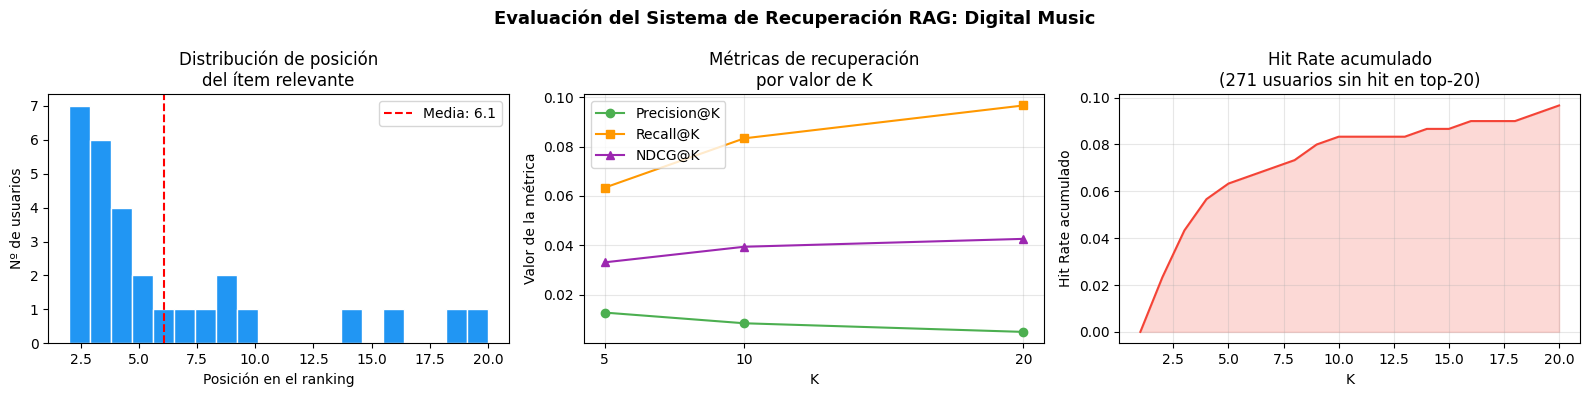

In [ ]:
# Análisis de la posición del ítem relevante

import matplotlib.pyplot as plt

hit_positions = df_metrics[df_metrics["hit_position"] > 0]["hit_position"]
no_hits       = (df_metrics["hit_position"] == -1).sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Evaluación del Sistema de Recuperación RAG: Digital Music",
             fontsize=13, fontweight="bold")

# Plot 1: Distribución de posición del ítem relevante
axes[0].hist(hit_positions, bins=20, color="#2196F3", edgecolor="white")
axes[0].axvline(hit_positions.mean(), color="red", linestyle="--",
                label=f"Media: {hit_positions.mean():.1f}")
axes[0].set_title("Distribución de posición\ndel ítem relevante")
axes[0].set_xlabel("Posición en el ranking")
axes[0].set_ylabel("Nº de usuarios")
axes[0].legend()

# Plot 2: Métricas @K (curva)
k_labels = K_VALUES
p_vals   = [means[f"P@{k}"] for k in k_labels]
r_vals   = [means[f"R@{k}"] for k in k_labels]
n_vals   = [means[f"NDCG@{k}"] for k in k_labels]

axes[1].plot(k_labels, p_vals, "o-", label="Precision@K", color="#4CAF50")
axes[1].plot(k_labels, r_vals, "s-", label="Recall@K",    color="#FF9800")
axes[1].plot(k_labels, n_vals, "^-", label="NDCG@K",      color="#9C27B0")
axes[1].set_title("Métricas de recuperación\npor valor de K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Valor de la métrica")
axes[1].set_xticks(k_labels)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Hit Rate acumulado
sorted_pos = sorted(hit_positions.tolist())
cum_hits   = [sum(1 for p in sorted_pos if p <= k) / len(df_metrics)
              for k in range(1, EVAL_K + 1)]

axes[2].plot(range(1, EVAL_K + 1), cum_hits, color="#F44336")
axes[2].fill_between(range(1, EVAL_K + 1), cum_hits, alpha=0.2, color="#F44336")
axes[2].set_title(f"Hit Rate acumulado\n({no_hits} usuarios sin hit en top-{EVAL_K})")
axes[2].set_xlabel("K")
axes[2].set_ylabel("Hit Rate acumulado")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Resumen final del proyecto

In [ ]:
print("*** Resumen final del Sistema de Recuperación RAG: Digital Music ***")

print(f"""
DATASET
  Colección      : Amazon Digital Music Reviews 2023
  Reseñas        : {len(reviews_raw):,}
  Ítems (corpus) : {len(df_corpus):,}
  Ítems con reseña: {len(reviews_text_by_asin):,}

INDEXACIÓN (Módulo I + II)
  Modelo embedding : all-MiniLM-L6-v2 (384 dims)
  Normalización    : L2 (coseno via IndexFlatIP)
  Índice FAISS     : IndexFlatIP - {index.ntotal:,} vectores

RECUPERACIÓN (Módulo II)
  Perfiles usuario : 6 (3 reales + 3 sintéticos)
  K recuperado     : {K} ítems por perfil
  Búsqueda         : matricial - index.search(queries, k)

GENERACIÓN LLM (Módulos III + IV)
  Modelo LLM       : Gemini 3 Flash
  Ítems al LLM     : {TOP_K_LLM} por perfil
  Ítems recomendados: 3 por perfil (re-ranked)

FILTRO ALUCINACIONES (Módulo V)
  Alucinaciones    : 0 / 18  ->  0.0%
  Re-rankings      : 12 / 18 -> 66.7% (el LLM mejoró el orden)

EVALUACIÓN (Módulo VI) - {len(eval_set)} usuarios de prueba
""")

for col in metric_cols:
    print(f"  {col:<10} : {means[col]:.4f}")
print(f"  {'Hit Rate':<10} : {hit_rate:.4f}  (top-{EVAL_K})")

*** Resumen final del Sistema de Recuperación RAG: Digital Music ***

DATASET
  Colección      : Amazon Digital Music Reviews 2023
  Reseñas        : 130,434
  Ítems (corpus) : 70,537
  Ítems con reseña: 70,511

INDEXACIÓN (Módulo I + II)
  Modelo embedding : all-MiniLM-L6-v2 (384 dims)
  Normalización    : L2 (coseno via IndexFlatIP)
  Índice FAISS     : IndexFlatIP — 70,537 vectores

RECUPERACIÓN (Módulo II)
  Perfiles usuario : 6 (3 reales + 3 sintéticos)
  K recuperado     : 20 ítems por perfil
  Búsqueda         : matricial — index.search(queries, k)

GENERACIÓN LLM (Módulos III + IV)
  Modelo LLM       : Gemini 3 Flash
  Ítems al LLM     : 10 por perfil
  Ítems recomendados: 3 por perfil (re-ranked)

FILTRO ALUCINACIONES (Módulo V)
  Alucinaciones    : 0 / 18  →  0.0%
  Re-rankings      : 12 / 18 → 66.7% (el LLM mejoró el orden)

EVALUACIÓN (Módulo VI) — 300 usuarios de prueba

  P@5        : 0.0127
  P@10       : 0.0083
  P@20       : 0.0048
  R@5        : 0.0633
  R@10       : 